<a href="https://colab.research.google.com/github/Ana-Franciscana/compet_visao/blob/AtividadeM2%2FAna-francisca/M2_Captura_Padronizada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dia 16/09 — M2: Captura padronizada (mobile)

**Capacitação PneumoVision** · IFPE · INPaR · Financiamento FACEPE

Nesta missão você grava um vídeo curto seguindo o protocolo (ver o material didático) e usa
este notebook para **conferir a qualidade** da sua gravação antes de entregar.

Sequencial e explicativo — cada parâmetro está comentado.

## 1. Preparação

In [90]:
import cv2                        # OpenCV: abrir e inspecionar o vídeo
import numpy as np              # NumPy: cálculos sobre os quadros (matrizes)
import matplotlib.pyplot as plt # matplotlib: exibir quadros no notebook

def mostrar(imagem, titulo=""):
    rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)  # BGR (OpenCV) -> RGB (matplotlib)
    plt.imshow(rgb)             # desenha a imagem
    plt.title(titulo)           # título
    plt.axis("off")             # esconde eixos
    plt.show()                  # renderiza

## 2. Um vídeo de exemplo (troque pelo seu)

Para o notebook rodar sem depender de arquivos, criamos um vídeo de exemplo. **Depois, troque
`CAMINHO_VIDEO` pelo caminho do seu vídeo** para conferir a sua gravação de verdade.

In [91]:
# Gera um vídeo de ~12 s (fundo cinza claro, um retângulo simulando a "mão")
fps = 10                                 # quadros por segundo
larg, alt = 640, 480                     # resolução (largura, altura)
fourcc = cv2.VideoWriter_fourcc(*"mp4v") # codec para arquivo .mp4
esc = cv2.VideoWriter(
    "exemplo_captura.mp4",               # arquivo de saída
    fourcc,                              # codec
    fps,                                # taxa de quadros
    (larg, alt),                        # frameSize (largura, altura)
)
for i in range(120):                     # 120 quadros / 10 fps = 12 s
    q = np.full((alt, larg, 3), 150, dtype=np.uint8)  # fundo cinza (150 = boa iluminação)
    x = 60 + i                            # posição que muda (simula movimento)
    cv2.rectangle(q, (x, 200), (x + 120, 320), (90, 120, 200), -1)  # "mão"
    esc.write(q)                          # grava o quadro
esc.release()                            # finaliza o arquivo
CAMINHO_VIDEO = "/video_m2.mp4"   # <-- troque pelo caminho do SEU vídeo
print("vídeo de exemplo criado")

vídeo de exemplo criado


In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*texto em itálico*# 3. Abrir e medir o vídeo

In [93]:
CAMINHO_VIDEO = "/video_m2.mp4" # Correcting the video path
cap = cv2.VideoCapture(CAMINHO_VIDEO)          # abre o vídeo (caminho do arquivo)
assert cap.isOpened(), "Não consegui abrir o vídeo"  # para se falhar

fps_v = cap.get(cv2.CAP_PROP_FPS)              # quadros por segundo
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # total de quadros
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))     # largura (pixels)
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))    # altura (pixels)
duracao = total / fps_v if fps_v else 0        # duração em segundos = quadros / fps
print(f"fps={fps_v} | quadros={total} | resolução={w}x{h} | duração={duracao:.1f}s")

fps=30.0 | quadros=558 | resolução=910x512 | duração=18.6s


## 4. Amostras de quadros

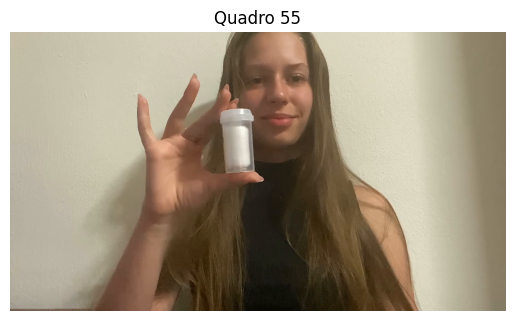

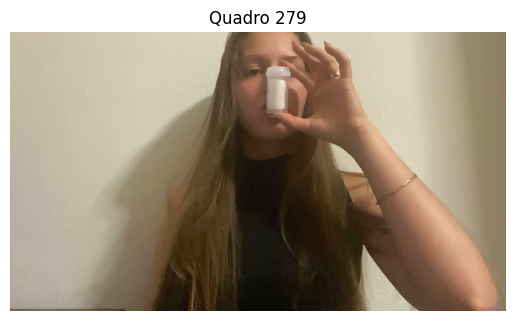

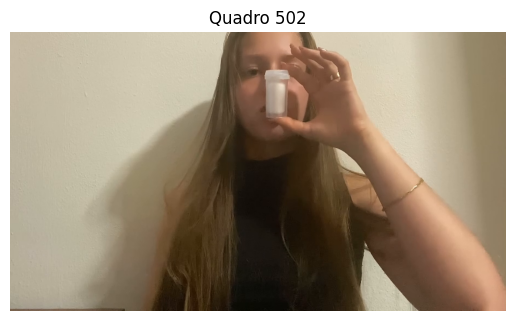

In [94]:
# Pega 3 quadros igualmente espaçados (início, meio, fim) para inspeção visual
indices = [int(total * f) for f in (0.1, 0.5, 0.9)]  # posições relativas
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)     # posiciona o leitor no quadro idx
    ok, q = cap.read()                        # lê aquele quadro
    if ok:                                     # se leu com sucesso
        mostrar(q, f"Quadro {idx}")           # exibe

## 5. Iluminação: brilho médio por quadro

Um vídeo escuro atrapalha a detecção de keypoints. Medimos o brilho médio (0 = preto,
255 = branco) para checar a iluminação.

brilho médio: 133.8 (ideal: entre ~60 e ~200)


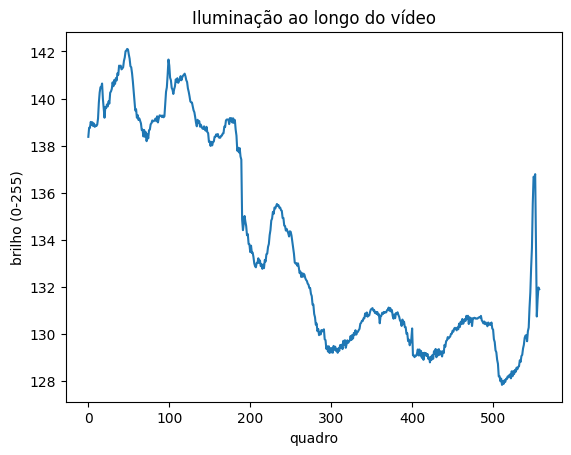

In [95]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)           # volta ao início
brilhos = []                                   # brilho médio de cada quadro
while True:
    ok, q = cap.read()                         # lê um quadro
    if not ok:                                 # fim do vídeo
        break
    cinza = cv2.cvtColor(q, cv2.COLOR_BGR2GRAY)  # brilho = imagem em cinza
    brilhos.append(float(np.mean(cinza)))      # média de todos os pixels
cap.release()                                  # libera o arquivo

brilho_medio = float(np.mean(brilhos))         # brilho médio do vídeo inteiro
print(f"brilho médio: {brilho_medio:.1f} (ideal: entre ~60 e ~200)")
plt.plot(brilhos)                              # curva de brilho ao longo do tempo
plt.xlabel("quadro"); plt.ylabel("brilho (0-255)"); plt.title("Iluminação ao longo do vídeo")
plt.show()

## 6. Checklist automático da gravação

In [97]:
def check(nome, condicao):                      # imprime PASSOU/ATENÇÃO para cada critério
    print(("✔ " if condicao else "✗ ATENÇÃO: ") + nome)

check("Duração entre 10 e 20 s", 10 <= duracao <= 20)      # duração no intervalo pedido
check("Resolução mínima 480p (altura >= 480)", h >= 480)    # resolução adequada
check("Iluminação adequada (brilho 60-200)", 60 <= brilho_medio <= 200)  # nem escuro, nem estourado
print("\nSe algum item deu ATENÇÃO, regrave ajustando o ponto indicado.")

✔ Duração entre 10 e 20 s
✔ Resolução mínima 480p (altura >= 480)
✔ Iluminação adequada (brilho 60-200)

Se algum item deu ATENÇÃO, regrave ajustando o ponto indicado.


## 7. Sua entrega (M2)

Grave, pelo celular, um vídeo de **10–20 s** simulando o uso de uma \"bombinha\" (pode ser um
objeto similar), seguindo o protocolo do material didático, e rode este notebook apontando
`CAMINHO_VIDEO` para o seu arquivo.

**Entregue no Classroom** o vídeo (.mp4).

**Critério de aceite:** duração 10–20 s; mãos visíveis e bem iluminadas; segue o enquadramento
do protocolo. Referência de dúvidas: Prof. Renan (captura mobile).